# Detector YOLO de Cilindros Industriais — BLAZE

Este notebook implementa o fluxo completo do módulo YOLO para detecção de cilindros industriais no projeto **BLAZE**.

Ele foi pensado para dois usos:

1. **Jupyter da UFSC**: treinamento com GPU compartilhada e seleção manual da GPU.
2. **VS Code local em Linux**: validação, inferência, webcam e vídeos após perder acesso ao servidor.

O notebook **não usa chave SSH, token ou senha**. O acesso ao repositório deve ser feito fora do notebook, pelo Git/terminal/VS Code.

## Passo 0 — Antes de abrir o notebook

No terminal, entre na pasta do BLAZE e confirme a branch:

```bash
cd caminho/para/BLAZE
git status
git branch --show-current
```

Fluxo recomendado:

```bash
git switch dev
git pull --ff-only
git switch -c feature/yolo-cylinders-notebook
```

Se você já criou uma branch para o módulo YOLO, use a branch existente.

## Passo 1 — Listar GPUs disponíveis

Esta célula usa `nvidia-smi` para mostrar quais GPUs existem no servidor e quanto de memória está livre.

No Jupyter da UFSC, execute antes de escolher a GPU. No VS Code local, se não houver GPU NVIDIA, o notebook seguirá em CPU.

In [4]:
import os
import subprocess
from pathlib import Path

try:
    import pandas as pd
except Exception:
    pd = None

def listar_gpus():
    comando = [
        "nvidia-smi",
        "--query-gpu=index,name,memory.total,memory.used,memory.free,utilization.gpu,temperature.gpu,power.draw,power.limit",
        "--format=csv,noheader,nounits"
    ]

    try:
        resultado = subprocess.check_output(comando, encoding="utf-8")
    except FileNotFoundError:
        print("nvidia-smi não encontrado. Provavelmente este ambiente não possui GPU NVIDIA configurada.")
        return pd.DataFrame([]) if pd is not None else []
    except subprocess.CalledProcessError as erro:
        print("Erro ao executar nvidia-smi:")
        print(erro)
        return pd.DataFrame([]) if pd is not None else []

    linhas = [linha for linha in resultado.strip().split("\n") if linha.strip()]
    dados = []

    for linha in linhas:
        partes = [p.strip() for p in linha.split(",")]
        dados.append({
            "GPU": int(partes[0]),
            "Nome": partes[1],
            "Memória total MiB": int(float(partes[2])),
            "Memória usada MiB": int(float(partes[3])),
            "Memória livre MiB": int(float(partes[4])),
            "Uso GPU %": int(float(partes[5])),
            "Temperatura °C": int(float(partes[6])),
            "Potência atual W": partes[7],
            "Potência limite W": partes[8],
        })

    if pd is not None:
        return pd.DataFrame(dados)

    return dados

df_gpus = listar_gpus()
df_gpus

nvidia-smi não encontrado. Provavelmente este ambiente não possui GPU NVIDIA configurada.


""


## Passo 2 — Escolher manualmente a GPU

Digite o número da GPU física escolhida.

Exemplo: se na tabela anterior a GPU mais livre é a `2`, digite `2`.

Depois desta célula, o Python/YOLO enxergará essa GPU como `device=0`.

In [5]:
# Deixe vazio para o notebook perguntar com input().
# Se preferir, escreva diretamente o número como texto. Exemplo: GPU_FISICA_ESCOLHIDA = "0"
GPU_FISICA_ESCOLHIDA = ""

if isinstance(df_gpus, list):
    gpus_disponiveis = [linha["GPU"] for linha in df_gpus]
else:
    gpus_disponiveis = df_gpus["GPU"].tolist() if len(df_gpus) > 0 else []

if len(gpus_disponiveis) == 0:
    print("Nenhuma GPU NVIDIA foi detectada. O notebook seguirá em CPU.")
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
else:
    gpu_texto = str(GPU_FISICA_ESCOLHIDA).strip()

    if gpu_texto == "":
        gpu_texto = input("Digite o número da GPU física que deseja usar: ").strip()

    if not gpu_texto.isdigit():
        raise ValueError("Digite apenas o número da GPU. Exemplo: 0, 1, 2, 3...")

    gpu_escolhida = int(gpu_texto)

    if gpu_escolhida not in gpus_disponiveis:
        raise ValueError(f"GPU {gpu_escolhida} não encontrada. GPUs disponíveis: {gpus_disponiveis}")

    # Importante: execute esta célula antes de importar torch/ultralytics.
    os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_escolhida)

    print(f"GPU física escolhida: {gpu_escolhida}")
    print("CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
    print("Dentro do Python/YOLO, essa GPU aparecerá como device=0.")

# Configurações auxiliares para ambiente remoto/Jupyter.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["WANDB_DISABLED"] = "true"

Nenhuma GPU NVIDIA foi detectada. O notebook seguirá em CPU.


## Passo 3 — Conferir GPU no Python

Agora o PyTorch deve enxergar apenas a GPU escolhida na célula anterior.

In [6]:
try:
    import torch

    print("CUDA disponível?", torch.cuda.is_available())
    print("Quantidade de GPUs visíveis para este notebook:", torch.cuda.device_count())

    if torch.cuda.is_available():
        print("Nome da GPU visível:", torch.cuda.get_device_name(0))
        DEVICE = 0
        DEVICE_YOLO = "0"
    else:
        DEVICE = "cpu"
        DEVICE_YOLO = "cpu"

except ImportError:
    print("PyTorch ainda não está instalado neste ambiente.")
    print("Execute a célula de instalação opcional abaixo, se necessário.")
    DEVICE = "cpu"
    DEVICE_YOLO = "cpu"

print("DEVICE usado pelo notebook:", DEVICE)
print("DEVICE_YOLO usado pelo Ultralytics:", DEVICE_YOLO)

CUDA disponível? False
Quantidade de GPUs visíveis para este notebook: 0
DEVICE usado pelo notebook: cpu
DEVICE_YOLO usado pelo Ultralytics: cpu


## Passo 4 — Instalação opcional

Use apenas se o ambiente ainda não tiver as bibliotecas necessárias.

Se instalar algo, reinicie o kernel e execute o notebook novamente desde o Passo 1.

In [7]:
# Execute somente se necessário.
# %pip install -U ultralytics pyyaml tqdm pandas matplotlib opencv-python

## Passo 5 — Importações principais

In [8]:
from pathlib import Path
import json
import random
import shutil
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, clear_output

try:
    from tqdm.notebook import tqdm
except Exception:
    from tqdm import tqdm

print("Importações concluídas.")

Importações concluídas.


## Passo 6 — Encontrar a raiz do projeto BLAZE

A célula tenta encontrar automaticamente a pasta raiz do BLAZE procurando `README.md`, `requirements.txt`, `vision/` e `jet_automation/`.

Se a detecção automática falhar, preencha manualmente `PROJECT_ROOT_MANUAL`.

In [9]:
# Caso a detecção automática falhe, preencha aqui.
# Exemplo: PROJECT_ROOT_MANUAL = "/home/jovyan/compartilhado/eduardofelipe/BLAZE"
PROJECT_ROOT_MANUAL = ""

def encontrar_raiz_blaze(inicio=None):
    env_root = os.environ.get("BLAZE_ROOT", "").strip()
    candidatos = []

    if PROJECT_ROOT_MANUAL.strip():
        candidatos.append(Path(PROJECT_ROOT_MANUAL).expanduser())

    if env_root:
        candidatos.append(Path(env_root).expanduser())

    if inicio is None:
        inicio = Path.cwd()

    inicio = Path(inicio).resolve()
    candidatos.extend([inicio] + list(inicio.parents))

    for candidato in candidatos:
        if (
            (candidato / "README.md").exists()
            and (candidato / "requirements.txt").exists()
            and (candidato / "vision").exists()
            and (candidato / "jet_automation").exists()
        ):
            return candidato.resolve()

    raise FileNotFoundError(
        "Não consegui encontrar a raiz do BLAZE automaticamente. "
        "Preencha PROJECT_ROOT_MANUAL com o caminho da pasta BLAZE."
    )

PROJECT_ROOT = encontrar_raiz_blaze()

print("Raiz do projeto BLAZE:")
print(PROJECT_ROOT)

Raiz do projeto BLAZE:
/home/eduardo/Documents/BLAZE


## Passo 7 — Configurar caminhos do módulo YOLO

O dataset e os resultados seguem o padrão atual do BLAZE:

- Dataset externo/ignorado pelo Git: `vision/datasets/cylinders/CylinDeRS-1/`
- Resultados externos/ignorados pelo Git: `vision/results/yolo_cylinder_detector/`
- Notebook versionado: `vision/cylinders_detect/YOLO/`

In [10]:
YOLO_MODULE_DIR = PROJECT_ROOT / "vision" / "cylinders_detect" / "YOLO"

DATASET_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "CylinDeRS-1"

RESULTS_BASE_DIR = PROJECT_ROOT / "vision" / "results" / "yolo_cylinder_detector"
TRAIN_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "train"
VAL_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "val"
PRED_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "predict"
VIDEO_PROJECT_DIR = RESULTS_BASE_DIR / "runs" / "video"

DATA_YAML_ORIGINAL = DATASET_DIR / "data.yaml"
DATA_YAML_LOCAL = DATASET_DIR / "data_local_blaze.yaml"

RUN_NAME = "yolov8n_cilindros_blaze_v1"

# Mantemos YOLOv8n porque o teste enviado já rodou corretamente com ele.
MODELO_BASE = "yolov8n.pt"

EPOCHS = 50
IMGSZ = 640
BATCH = 8
CONF = 0.35
IOU = 0.50

CLASSES = ["cylinder"]

for pasta in [RESULTS_BASE_DIR, TRAIN_PROJECT_DIR, VAL_PROJECT_DIR, PRED_PROJECT_DIR, VIDEO_PROJECT_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

RUN_DIR = TRAIN_PROJECT_DIR / RUN_NAME
WEIGHTS_DIR = RUN_DIR / "weights"
BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

print("YOLO_MODULE_DIR:", YOLO_MODULE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("RESULTS_BASE_DIR:", RESULTS_BASE_DIR)
print("DATA_YAML_ORIGINAL:", DATA_YAML_ORIGINAL)
print("DATA_YAML_LOCAL:", DATA_YAML_LOCAL)
print("RUN_DIR:", RUN_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)

YOLO_MODULE_DIR: /home/eduardo/Documents/BLAZE/vision/cylinders_detect/YOLO
DATASET_DIR: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1
RESULTS_BASE_DIR: /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector
DATA_YAML_ORIGINAL: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/data.yaml
DATA_YAML_LOCAL: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml
RUN_DIR: /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1
BEST_MODEL_PATH: /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1/weights/best.pt


## Passo 8 — Verificar se o dataset existe

In [11]:
print("PROJECT_ROOT existe?", PROJECT_ROOT.exists())
print("YOLO_MODULE_DIR existe?", YOLO_MODULE_DIR.exists())
print("DATASET_DIR existe?", DATASET_DIR.exists())
print("DATA_YAML_ORIGINAL existe?", DATA_YAML_ORIGINAL.exists())

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em: {DATASET_DIR}\n"
        "Confirme a instalação do CylinDeRS-1 conforme INSTALACAO_DADOS.md."
    )

print("\nConteúdo inicial do DATASET_DIR:")
for item in sorted(DATASET_DIR.iterdir()):
    print("-", item.name)

PROJECT_ROOT existe? True
YOLO_MODULE_DIR existe? True
DATASET_DIR existe? True
DATA_YAML_ORIGINAL existe? True

Conteúdo inicial do DATASET_DIR:
- README.dataset.txt
- README.roboflow.txt
- data.yaml
- data_local.yaml
- data_local_blaze.yaml
- test
- train
- valid


## Passo 9 — Detectar splits do dataset

Alguns datasets YOLO usam `train/valid/test`; outros usam `train/val/test`.

In [12]:
def detectar_split_dir(dataset_dir, nomes_possiveis):
    for nome in nomes_possiveis:
        candidato = dataset_dir / nome
        if candidato.exists():
            return nome
    return None

SPLIT_TRAIN = detectar_split_dir(DATASET_DIR, ["train", "training"])
SPLIT_VAL = detectar_split_dir(DATASET_DIR, ["valid", "val", "validation"])
SPLIT_TEST = detectar_split_dir(DATASET_DIR, ["test", "testing"])

print("Split de treino:", SPLIT_TRAIN)
print("Split de validação:", SPLIT_VAL)
print("Split de teste:", SPLIT_TEST)

if SPLIT_TRAIN is None:
    raise FileNotFoundError("Não encontrei pasta de treino. Esperado: train/images.")

if SPLIT_VAL is None:
    raise FileNotFoundError("Não encontrei pasta de validação. Esperado: valid/images ou val/images.")

if SPLIT_TEST is None:
    print("Aviso: não encontrei pasta de teste. O notebook continuará usando treino/validação.")

Split de treino: train
Split de validação: valid
Split de teste: test


## Passo 10 — Verificar imagens e labels

No formato YOLO, cada imagem deve ter um `.txt` correspondente na pasta `labels`.

In [13]:
EXT_IMAGENS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"]

def listar_imagens(pasta):
    if not pasta.exists():
        return []
    imagens = []
    for ext in EXT_IMAGENS:
        imagens.extend(pasta.glob(f"*{ext}"))
        imagens.extend(pasta.glob(f"*{ext.upper()}"))
    return sorted(set(imagens))

def resumo_split(nome_split):
    img_dir = DATASET_DIR / nome_split / "images"
    label_dir = DATASET_DIR / nome_split / "labels"

    imagens = listar_imagens(img_dir)
    labels = sorted(label_dir.glob("*.txt")) if label_dir.exists() else []

    print(f"\n=== {nome_split.upper()} ===")
    print("Pasta de imagens:", img_dir)
    print("Existe?", img_dir.exists())
    print("Quantidade de imagens:", len(imagens))
    print("Pasta de labels:", label_dir)
    print("Existe?", label_dir.exists())
    print("Quantidade de labels:", len(labels))

    imagens_stem = {p.stem for p in imagens}
    labels_stem = {p.stem for p in labels}

    print("Imagens sem label:", len(imagens_stem - labels_stem))
    print("Labels sem imagem:", len(labels_stem - imagens_stem))

    return {
        "split": nome_split,
        "img_dir": img_dir,
        "label_dir": label_dir,
        "imagens": imagens,
        "labels": labels,
        "imagens_sem_label": sorted(imagens_stem - labels_stem),
        "labels_sem_imagem": sorted(labels_stem - imagens_stem),
    }

resumos = {}
for split in [SPLIT_TRAIN, SPLIT_VAL, SPLIT_TEST]:
    if split is not None:
        resumos[split] = resumo_split(split)


=== TRAIN ===
Pasta de imagens: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/train/images
Existe? True
Quantidade de imagens: 4915
Pasta de labels: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/train/labels
Existe? True
Quantidade de labels: 4915
Imagens sem label: 0
Labels sem imagem: 0

=== VALID ===
Pasta de imagens: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/valid/images
Existe? True
Quantidade de imagens: 1434
Pasta de labels: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/valid/labels
Existe? True
Quantidade de labels: 1434
Imagens sem label: 0
Labels sem imagem: 0

=== TEST ===
Pasta de imagens: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/test/images
Existe? True
Quantidade de imagens: 711
Pasta de labels: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/test/labels
Existe? True
Quantidade de labels: 711
Imagens sem label: 0
Labels sem imagem: 0


## Passo 11 — Ler o `data.yaml` original

Se o dataset veio do Roboflow ou de outra ferramenta, o `data.yaml` pode conter caminhos que não funcionam no BLAZE. Por isso criaremos um YAML local corrigido.

In [14]:
if DATA_YAML_ORIGINAL.exists():
    with open(DATA_YAML_ORIGINAL, "r", encoding="utf-8") as f:
        data_original = yaml.safe_load(f)

    print("Conteúdo do data.yaml original:")
    print(json.dumps(data_original, indent=2, ensure_ascii=False))
else:
    print("data.yaml original não encontrado.")
    data_original = None

Conteúdo do data.yaml original:
{
  "names": [
    "gas_cylinder"
  ],
  "nc": 1,
  "roboflow": {
    "license": "CC BY 4.0",
    "project": "cylinders_new4_wscript",
    "url": "https://universe.roboflow.com/cylindersnew/cylinders_new4_wscript/dataset/1",
    "version": 1,
    "workspace": "cylindersnew"
  },
  "test": "../test/images",
  "train": "../train/images",
  "val": "../valid/images"
}


## Passo 12 — Criar `data_local_blaze.yaml`

Este arquivo é gerado localmente dentro do dataset e não precisa ser versionado.

In [15]:
data_local = {
    "path": str(DATASET_DIR),
    "train": f"{SPLIT_TRAIN}/images",
    "val": f"{SPLIT_VAL}/images",
    "nc": 1,
    "names": CLASSES,
}

if SPLIT_TEST is not None:
    data_local["test"] = f"{SPLIT_TEST}/images"

with open(DATA_YAML_LOCAL, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_local, f, sort_keys=False, allow_unicode=True)

print("Arquivo criado:")
print(DATA_YAML_LOCAL)

print("\nConteúdo:")
print(DATA_YAML_LOCAL.read_text(encoding="utf-8"))

Arquivo criado:
/home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml

Conteúdo:
path: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1
train: train/images
val: valid/images
nc: 1
names:
- cylinder
test: test/images



## Passo 13 — Validar o YAML local

In [16]:
with open(DATA_YAML_LOCAL, "r", encoding="utf-8") as f:
    data_check = yaml.safe_load(f)

base_path = Path(data_check["path"])

for chave in ["train", "val", "test"]:
    if chave in data_check:
        caminho = base_path / data_check[chave]
        print(f"{chave}:", caminho, "| existe?", caminho.exists())
        if not caminho.exists():
            raise FileNotFoundError(f"Caminho do split {chave} não encontrado: {caminho}")

print("\nClasses:", data_check["names"])
print("Número de classes:", data_check["nc"])

train: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/train/images | existe? True
val: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/valid/images | existe? True
test: /home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/test/images | existe? True

Classes: ['cylinder']
Número de classes: 1


## Passo 14 — Verificar conteúdo das labels YOLO

Formato esperado de cada linha:

```text
classe x_centro y_centro largura altura
```

Os valores de posição e tamanho devem estar normalizados entre 0 e 1.

In [17]:
def verificar_labels_yolo(label_path):
    erros = []
    linhas_validas = 0
    instancias = 0

    if not label_path.exists():
        return linhas_validas, instancias, erros

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = f.readlines()

    for idx, linha in enumerate(linhas, start=1):
        linha_limpa = linha.strip()

        if linha_limpa == "":
            continue

        partes = linha_limpa.split()

        if len(partes) != 5:
            erros.append(f"{label_path.name}: linha {idx} possui {len(partes)} campos, esperado 5.")
            continue

        try:
            classe = int(float(partes[0]))
            valores = [float(v) for v in partes[1:]]
        except ValueError:
            erros.append(f"{label_path.name}: linha {idx} possui valores não numéricos.")
            continue

        if classe < 0 or classe >= len(CLASSES):
            erros.append(f"{label_path.name}: linha {idx} possui classe inválida: {classe}.")

        if not all(0.0 <= v <= 1.0 for v in valores):
            erros.append(f"{label_path.name}: linha {idx} possui coordenadas fora de [0, 1]: {valores}.")

        if valores[2] <= 0 or valores[3] <= 0:
            erros.append(f"{label_path.name}: linha {idx} possui largura/altura inválida: {valores[2:]}.")

        linhas_validas += 1
        instancias += 1

    return linhas_validas, instancias, erros

todos_erros = []
total_instancias = 0

for split, info in resumos.items():
    split_instancias = 0

    for label_path in info["labels"]:
        _, instancias, erros = verificar_labels_yolo(label_path)
        split_instancias += instancias
        todos_erros.extend([f"[{split}] {erro}" for erro in erros])

    total_instancias += split_instancias
    print(f"{split}: instâncias anotadas = {split_instancias}")

print("\nTotal de instâncias anotadas:", total_instancias)
print("Total de erros encontrados:", len(todos_erros))

if todos_erros:
    print("\nPrimeiros erros:")
    for erro in todos_erros[:20]:
        print("-", erro)
else:
    print("Nenhum erro estrutural encontrado nas labels.")

train: instâncias anotadas = 18133
valid: instâncias anotadas = 4862
test: instâncias anotadas = 2270

Total de instâncias anotadas: 25265
Total de erros encontrados: 4

Primeiros erros:
- [train] L042_jpg.rf.1e16e1981a021005b07e4265ba1d4282.txt: linha 3 possui 13 campos, esperado 5.
- [train] LPG-10-_jpg.rf.b39830121e005cecadf70050f442d6f3.txt: linha 2 possui 11 campos, esperado 5.
- [train] ps0006-00-580-_jpg.rf.017f78bf2d627a411a3273c95fe8a456.txt: linha 1 possui 19 campos, esperado 5.
- [train] ps0006-00-580-_jpg.rf.017f78bf2d627a411a3273c95fe8a456.txt: linha 2 possui 17 campos, esperado 5.


## Passo 15 — Criar labels vazios para imagens sem anotação

Pode existir imagem sem objeto. Nesse caso, o arquivo `.txt` pode ficar vazio.

Por segurança, esta célula só cria labels vazios se `CRIAR_LABELS_VAZIOS = True`.

In [18]:
CRIAR_LABELS_VAZIOS = False

if not CRIAR_LABELS_VAZIOS:
    print("Nenhum arquivo será criado. Para criar labels vazios, altere CRIAR_LABELS_VAZIOS = True.")
else:
    for split, info in resumos.items():
        label_dir = info["label_dir"]
        label_dir.mkdir(parents=True, exist_ok=True)

        criados = 0
        for stem in info["imagens_sem_label"]:
            label_path = label_dir / f"{stem}.txt"
            if not label_path.exists():
                label_path.write_text("", encoding="utf-8")
                criados += 1

        print(f"{split}: labels vazios criados = {criados}")

Nenhum arquivo será criado. Para criar labels vazios, altere CRIAR_LABELS_VAZIOS = True.


## Passo 16 — Funções para visualizar anotações

In [19]:
def carregar_labels_yolo(label_path):
    labels = []

    if not label_path.exists():
        return labels

    with open(label_path, "r", encoding="utf-8") as f:
        linhas = f.readlines()

    for linha in linhas:
        valores = linha.strip().split()

        if len(valores) == 5:
            classe, x_c, y_c, w, h = valores
            labels.append([
                int(float(classe)),
                float(x_c),
                float(y_c),
                float(w),
                float(h)
            ])

    return labels

def desenhar_bbox_yolo(img_rgb, labels, nomes_classes=None):
    if nomes_classes is None:
        nomes_classes = CLASSES

    img_draw = img_rgb.copy()
    altura, largura = img_draw.shape[:2]

    for classe, x_c, y_c, w, h in labels:
        x_c_px = x_c * largura
        y_c_px = y_c * altura
        w_px = w * largura
        h_px = h * altura

        x1 = int(x_c_px - w_px / 2)
        y1 = int(y_c_px - h_px / 2)
        x2 = int(x_c_px + w_px / 2)
        y2 = int(y_c_px + h_px / 2)

        x1 = max(0, min(x1, largura - 1))
        x2 = max(0, min(x2, largura - 1))
        y1 = max(0, min(y1, altura - 1))
        y2 = max(0, min(y2, altura - 1))

        nome = nomes_classes[classe] if classe < len(nomes_classes) else str(classe)

        cv2.rectangle(img_draw, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            img_draw,
            nome,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

    return img_draw

## Passo 17 — Mostrar amostras anotadas

Use para conferir visualmente se as caixas estão corretas.

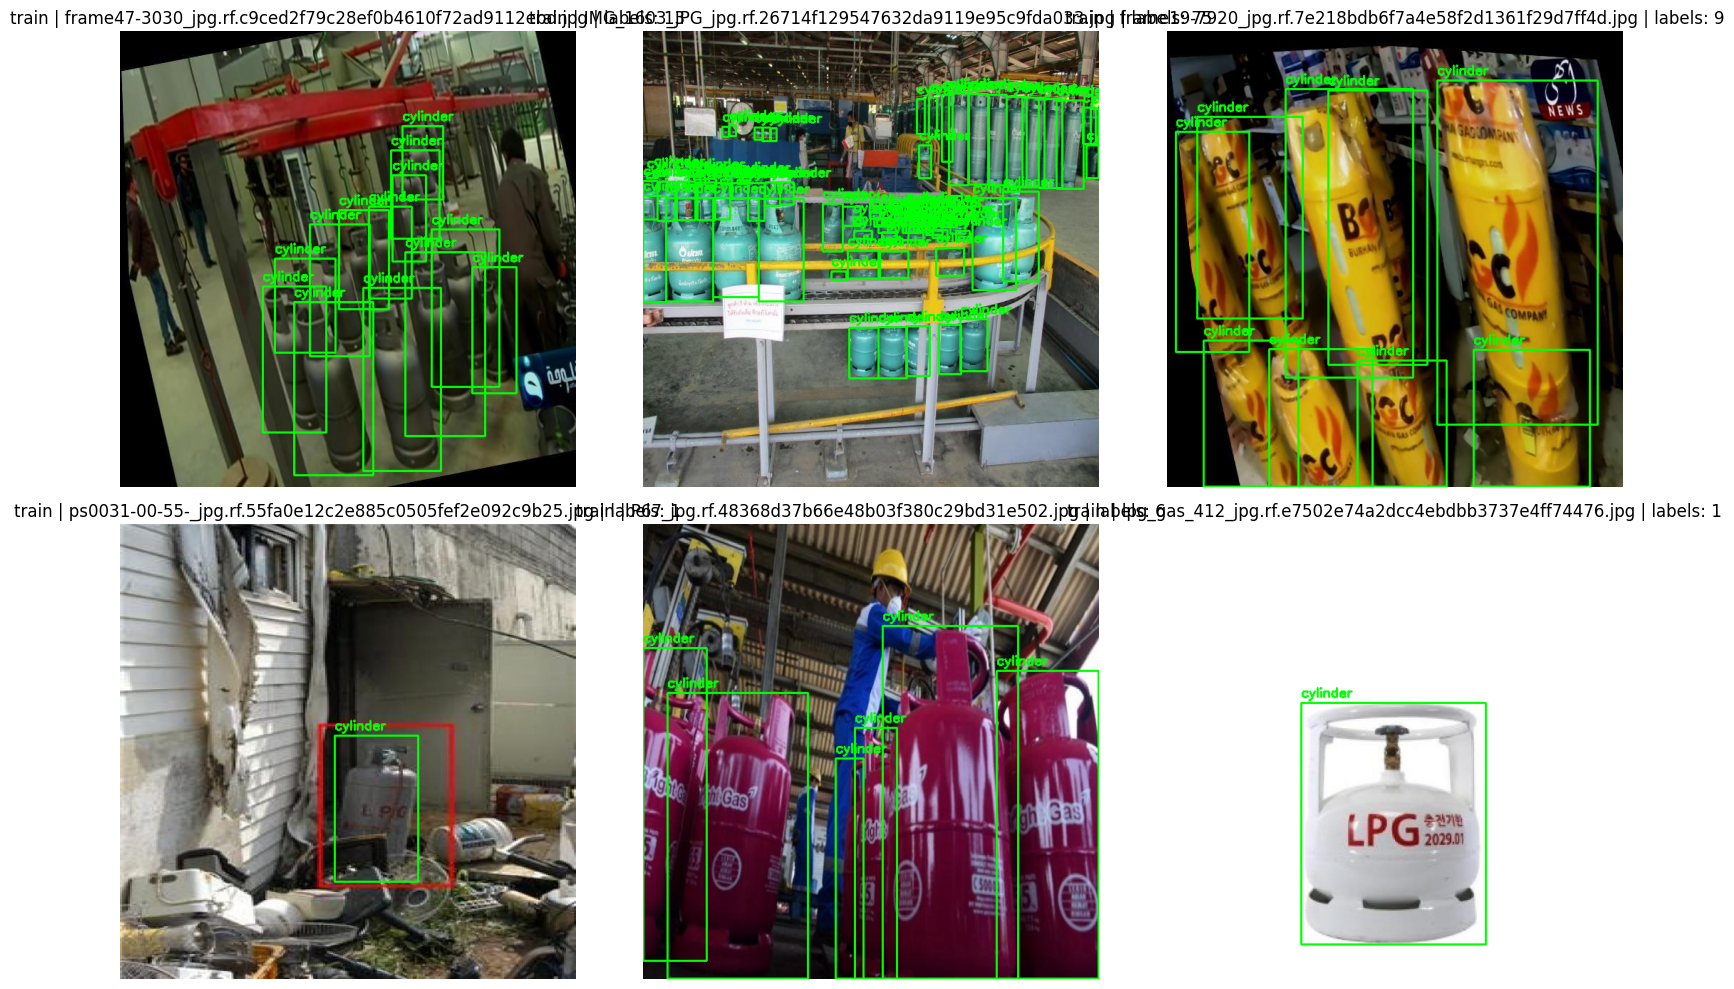

In [20]:
def mostrar_amostras(split=None, n=6):
    if split is None:
        split = SPLIT_TRAIN

    img_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    imagens = listar_imagens(img_dir)

    if len(imagens) == 0:
        print("Nenhuma imagem encontrada.")
        return

    amostras = random.sample(imagens, min(n, len(imagens)))

    cols = 3
    rows = (len(amostras) + cols - 1) // cols

    plt.figure(figsize=(16, 5 * rows))

    for i, img_path in enumerate(amostras):
        img_bgr = cv2.imread(str(img_path))

        if img_bgr is None:
            print("Erro ao ler:", img_path)
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        label_path = label_dir / f"{img_path.stem}.txt"
        labels = carregar_labels_yolo(label_path)

        img_draw = desenhar_bbox_yolo(img_rgb, labels)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_draw)
        plt.title(f"{split} | {img_path.name} | labels: {len(labels)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_amostras(SPLIT_TRAIN, n=6)

## Passo 18 — Conferir versão do Ultralytics

In [21]:
try:
    import ultralytics
    from ultralytics import YOLO

    print("Ultralytics instalado.")
    print("Versão:", ultralytics.__version__)
except ImportError as erro:
    raise ImportError(
        "O pacote ultralytics não está instalado. "
        "Execute a célula de instalação opcional e reinicie o kernel."
    ) from erro

Ultralytics instalado.
Versão: 8.4.58


## Passo 19 — Treinar o modelo YOLO com continuação automática

Esta célula é a célula oficial de treinamento.

Ela faz automaticamente:

- verifica se já existe treinamento anterior;
- se encontrar `last.pt`, continua a partir dos pesos salvos;
- se não encontrar pesos, inicia do modelo base;
- evita `resume=True` dentro do Jupyter para não gerar erro de multiprocessing;
- atualiza `BEST_MODEL_PATH`, `LAST_MODEL_PATH` e `RUN_DIR` para as próximas etapas.

> Observação: esta continuação é feita a partir dos pesos salvos em `last.pt`. Ela é mais estável no Jupyter remoto do que `resume=True`, mas não retoma exatamente o estado interno do otimizador.

In [22]:
# ============================================================
# Passo 19 — Modelo YOLO: usar peso oficial ou treinar
# ============================================================
#
# Esta célula centraliza duas opções:
#
# 1. Usar peso oficial da GitHub Release
#    - baixa o peso treinado se ele não existir localmente;
#    - verifica SHA-256;
#    - configura BEST_MODEL_PATH para validação/inferência;
#    - permite usar o modelo sem treinar novamente.
#
# 2. Treinar ou continuar treinamento
#    - detecta execuções anteriores;
#    - se existir last.pt, continua a partir dele;
#    - se não existir, inicia do modelo base;
#    - evita resume=True no Jupyter para não gerar erro de multiprocessing.
# ============================================================

import json
import hashlib
import urllib.request
from pathlib import Path
from datetime import datetime

import pandas as pd
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


# ------------------------------------------------------------
# Configurações do peso oficial
# ------------------------------------------------------------

YOLO_RELEASE_TAG = "v0.2.0-yolo-cylinders"

YOLO_OFFICIAL_WEIGHT_NAME = "yolo_cylinders_best.pt"
YOLO_OFFICIAL_SHA_NAME = "yolo_cylinders_best.sha256"

YOLO_OFFICIAL_WEIGHT_URL = (
    f"https://github.com/Ekamitani/BLAZE/releases/download/"
    f"{YOLO_RELEASE_TAG}/{YOLO_OFFICIAL_WEIGHT_NAME}"
)

YOLO_OFFICIAL_SHA_URL = (
    f"https://github.com/Ekamitani/BLAZE/releases/download/"
    f"{YOLO_RELEASE_TAG}/{YOLO_OFFICIAL_SHA_NAME}"
)

YOLO_OFFICIAL_WEIGHTS_DIR = (
    PROJECT_ROOT
    / "vision"
    / "results"
    / "yolo_cylinder_detector"
    / "weights"
)

YOLO_OFFICIAL_WEIGHT_PATH = YOLO_OFFICIAL_WEIGHTS_DIR / YOLO_OFFICIAL_WEIGHT_NAME
YOLO_OFFICIAL_SHA_PATH = YOLO_OFFICIAL_WEIGHTS_DIR / YOLO_OFFICIAL_SHA_NAME


# ------------------------------------------------------------
# Configurações de treinamento
# ------------------------------------------------------------

CONTINUAR_TREINO_SE_EXISTIR = True
FORCAR_TREINO_DO_ZERO = False
CRIAR_NOVA_EXECUCAO_AO_CONTINUAR = True
STATUS_FILE_NAME = "blaze_training_status.json"


# ------------------------------------------------------------
# Funções do peso oficial
# ------------------------------------------------------------

def baixar_arquivo(url, destino):
    destino = Path(destino)
    destino.parent.mkdir(parents=True, exist_ok=True)

    print("Baixando:")
    print(url)
    print("Destino:")
    print(destino)

    urllib.request.urlretrieve(url, destino)

    print("Download concluído.")


def calcular_sha256(caminho):
    caminho = Path(caminho)
    h = hashlib.sha256()

    with open(caminho, "rb") as f:
        for bloco in iter(lambda: f.read(1024 * 1024), b""):
            h.update(bloco)

    return h.hexdigest()


def ler_sha256_esperado(caminho_sha):
    texto = Path(caminho_sha).read_text(encoding="utf-8").strip()
    return texto.split()[0]


def usar_peso_oficial():
    """
    Baixa e configura o peso oficial da GitHub Release.
    """
    global BEST_MODEL_PATH, LAST_MODEL_PATH, RUN_DIR, WEIGHTS_DIR

    YOLO_OFFICIAL_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

    print("=== USO DO PESO OFICIAL ===")
    print("Release:", YOLO_RELEASE_TAG)
    print("Pasta local:", YOLO_OFFICIAL_WEIGHTS_DIR)
    print()

    if YOLO_OFFICIAL_WEIGHT_PATH.exists():
        print("Peso oficial já existe localmente:")
        print(YOLO_OFFICIAL_WEIGHT_PATH)
    else:
        baixar_arquivo(YOLO_OFFICIAL_WEIGHT_URL, YOLO_OFFICIAL_WEIGHT_PATH)

    print()

    if YOLO_OFFICIAL_SHA_PATH.exists():
        print("Arquivo SHA-256 já existe localmente:")
        print(YOLO_OFFICIAL_SHA_PATH)
    else:
        baixar_arquivo(YOLO_OFFICIAL_SHA_URL, YOLO_OFFICIAL_SHA_PATH)

    sha_esperado = ler_sha256_esperado(YOLO_OFFICIAL_SHA_PATH)
    sha_calculado = calcular_sha256(YOLO_OFFICIAL_WEIGHT_PATH)

    print("\n=== VERIFICAÇÃO SHA-256 ===")
    print("Esperado: ", sha_esperado)
    print("Calculado:", sha_calculado)

    if sha_esperado != sha_calculado:
        raise RuntimeError(
            "Falha na verificação SHA-256 do peso oficial.\n"
            "Apague o arquivo .pt local e rode esta opção novamente."
        )

    print("SHA-256 verificado com sucesso.")

    BEST_MODEL_PATH = YOLO_OFFICIAL_WEIGHT_PATH
    LAST_MODEL_PATH = YOLO_OFFICIAL_WEIGHT_PATH
    RUN_DIR = YOLO_OFFICIAL_WEIGHTS_DIR
    WEIGHTS_DIR = YOLO_OFFICIAL_WEIGHTS_DIR

    print("\n=== PESO OFICIAL CONFIGURADO ===")
    print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
    print("Existe?", BEST_MODEL_PATH.exists())
    print()
    print("Agora você pode seguir para validação, inferência em imagem, vídeo ou webcam.")
    print("Não é necessário treinar novamente.")


# ------------------------------------------------------------
# Funções de treinamento/continuação
# ------------------------------------------------------------

def contar_epocas_no_results_csv(run_dir):
    results_csv = Path(run_dir) / "results.csv"

    if not results_csv.exists():
        return 0

    try:
        df = pd.read_csv(results_csv)
        return len(df)
    except Exception as e:
        print(f"Aviso: não foi possível ler {results_csv}")
        print("Erro:", e)
        return 0


def ler_status_blaze(run_dir):
    status_path = Path(run_dir) / STATUS_FILE_NAME

    if not status_path.exists():
        return {
            "epochs_before_this_run": 0,
            "target_total_epochs": EPOCHS,
            "source_checkpoint": None,
        }

    try:
        with open(status_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {
            "epochs_before_this_run": 0,
            "target_total_epochs": EPOCHS,
            "source_checkpoint": None,
        }


def salvar_status_blaze(run_dir, status):
    run_dir = Path(run_dir)
    run_dir.mkdir(parents=True, exist_ok=True)

    status_path = run_dir / STATUS_FILE_NAME

    with open(status_path, "w", encoding="utf-8") as f:
        json.dump(status, f, indent=4, ensure_ascii=False)


def obter_info_execucao(run_dir):
    run_dir = Path(run_dir)

    weights_dir = run_dir / "weights"
    best_path = weights_dir / "best.pt"
    last_path = weights_dir / "last.pt"

    status = ler_status_blaze(run_dir)

    epocas_nesta_execucao = contar_epocas_no_results_csv(run_dir)
    epocas_anteriores = int(status.get("epochs_before_this_run", 0))
    epocas_totais_estimadas = epocas_anteriores + epocas_nesta_execucao

    if last_path.exists():
        mtime = last_path.stat().st_mtime
    elif best_path.exists():
        mtime = best_path.stat().st_mtime
    elif run_dir.exists():
        mtime = run_dir.stat().st_mtime
    else:
        mtime = 0

    return {
        "run_dir": run_dir,
        "weights_dir": weights_dir,
        "best_path": best_path,
        "last_path": last_path,
        "status": status,
        "epocas_nesta_execucao": epocas_nesta_execucao,
        "epocas_anteriores": epocas_anteriores,
        "epocas_totais_estimadas": epocas_totais_estimadas,
        "mtime": mtime,
        "tem_best": best_path.exists(),
        "tem_last": last_path.exists(),
    }


def encontrar_execucoes_do_treino():
    train_project_dir = Path(TRAIN_PROJECT_DIR)

    if not train_project_dir.exists():
        return []

    execucoes = []

    for item in train_project_dir.iterdir():
        if item.is_dir() and item.name.startswith(RUN_NAME):
            info = obter_info_execucao(item)

            if info["tem_last"] or info["tem_best"]:
                execucoes.append(info)

    execucoes = sorted(
        execucoes,
        key=lambda x: (x["epocas_totais_estimadas"], x["mtime"]),
        reverse=True,
    )

    return execucoes


def mostrar_resumo_execucoes(execucoes):
    if not execucoes:
        print("Nenhuma execução anterior encontrada.")
        return

    print("Execuções anteriores encontradas:\n")

    for i, info in enumerate(execucoes, start=1):
        print(f"[{i}] {info['run_dir'].name}")
        print(f"    Épocas nesta execução: {info['epocas_nesta_execucao']}")
        print(f"    Épocas anteriores:      {info['epocas_anteriores']}")
        print(f"    Total estimado:         {info['epocas_totais_estimadas']}/{EPOCHS}")
        print(f"    best.pt:                {info['tem_best']}")
        print(f"    last.pt:                {info['tem_last']}")
        print()


def treinar_ou_continuar():
    """
    Executa treinamento novo ou continuação automática.
    """
    global BEST_MODEL_PATH, LAST_MODEL_PATH, RUN_DIR, WEIGHTS_DIR

    print("=== CONFIGURAÇÃO DO TREINAMENTO ===")
    print("Modelo base:", MODELO_BASE)
    print("Dataset YAML:", DATA_YAML_LOCAL)
    print("Train project dir:", TRAIN_PROJECT_DIR)
    print("Run base:", RUN_NAME)
    print("Epochs desejadas:", EPOCHS)
    print("Image size:", IMGSZ)
    print("Batch:", BATCH)
    print("DEVICE_YOLO:", DEVICE_YOLO)
    print()

    if not Path(DATA_YAML_LOCAL).exists():
        raise FileNotFoundError(f"Arquivo data.yaml não encontrado: {DATA_YAML_LOCAL}")

    if torch.cuda.is_available():
        print("CUDA disponível.")
        print("GPU visível para o notebook:", torch.cuda.get_device_name(0))
        torch.cuda.empty_cache()
    else:
        print("CUDA não disponível. O treino será feito em CPU.")

    print()

    execucoes = encontrar_execucoes_do_treino()
    mostrar_resumo_execucoes(execucoes)

    execucao_referencia = execucoes[0] if execucoes else None

    if FORCAR_TREINO_DO_ZERO:
        modo_treino = "novo"
        checkpoint_inicial = MODELO_BASE
        epocas_ja_feitas = 0
        epocas_para_treinar = EPOCHS

    elif (
        CONTINUAR_TREINO_SE_EXISTIR
        and execucao_referencia is not None
        and execucao_referencia["tem_last"]
    ):
        epocas_ja_feitas = execucao_referencia["epocas_totais_estimadas"]

        if epocas_ja_feitas >= EPOCHS:
            modo_treino = "pular"
            checkpoint_inicial = execucao_referencia["last_path"]
            epocas_para_treinar = 0
        else:
            modo_treino = "continuar"
            checkpoint_inicial = execucao_referencia["last_path"]
            epocas_para_treinar = max(EPOCHS - epocas_ja_feitas, 1)

    else:
        modo_treino = "novo"
        checkpoint_inicial = MODELO_BASE
        epocas_ja_feitas = 0
        epocas_para_treinar = EPOCHS

    print("=== DECISÃO AUTOMÁTICA ===")
    print("Modo:", modo_treino)
    print("Checkpoint/modelo inicial:", checkpoint_inicial)
    print("Épocas já feitas:", epocas_ja_feitas)
    print("Épocas que serão treinadas agora:", epocas_para_treinar)
    print()

    if modo_treino == "pular":
        print("O treinamento já parece ter atingido o total desejado de épocas.")
        print("Nenhum novo treinamento será iniciado.")

        RUN_DIR = execucao_referencia["run_dir"]
        WEIGHTS_DIR = execucao_referencia["weights_dir"]
        BEST_MODEL_PATH = execucao_referencia["best_path"]
        LAST_MODEL_PATH = execucao_referencia["last_path"]

    else:
        if modo_treino == "novo":
            run_name_atual = RUN_NAME
            epochs_before_this_run = 0

        elif modo_treino == "continuar":
            if CRIAR_NOVA_EXECUCAO_AO_CONTINUAR:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                run_name_atual = f"{RUN_NAME}_cont_{timestamp}"
            else:
                run_name_atual = RUN_NAME

            epochs_before_this_run = epocas_ja_feitas

        RUN_DIR = Path(TRAIN_PROJECT_DIR) / run_name_atual
        WEIGHTS_DIR = RUN_DIR / "weights"
        BEST_MODEL_PATH = WEIGHTS_DIR / "best.pt"
        LAST_MODEL_PATH = WEIGHTS_DIR / "last.pt"

        status_inicial = {
            "project": "BLAZE",
            "module": "vision/cylinders_detect/YOLO",
            "run_name": run_name_atual,
            "mode": modo_treino,
            "source_checkpoint": str(checkpoint_inicial),
            "epochs_before_this_run": int(epochs_before_this_run),
            "epochs_requested_this_run": int(epocas_para_treinar),
            "target_total_epochs": int(EPOCHS),
            "data_yaml": str(DATA_YAML_LOCAL),
            "created_at": datetime.now().isoformat(timespec="seconds"),
        }

        salvar_status_blaze(RUN_DIR, status_inicial)

        print("Iniciando treinamento...")
        print("Run atual:", run_name_atual)
        print("Pasta da execução:", RUN_DIR)
        print()

        model = YOLO(str(checkpoint_inicial))

        results = model.train(
            data=str(DATA_YAML_LOCAL),
            epochs=epocas_para_treinar,
            imgsz=IMGSZ,
            batch=BATCH,
            device=DEVICE_YOLO,
            workers=0,
            cache=False,
            project=str(TRAIN_PROJECT_DIR),
            name=run_name_atual,
            exist_ok=True,
            plots=True,
            verbose=False,
        )

        status_final = status_inicial.copy()
        status_final["finished_at"] = datetime.now().isoformat(timespec="seconds")
        status_final["epochs_completed_this_run"] = contar_epocas_no_results_csv(RUN_DIR)
        status_final["estimated_total_epochs_completed"] = (
            status_final["epochs_before_this_run"]
            + status_final["epochs_completed_this_run"]
        )
        status_final["best_model_path"] = str(BEST_MODEL_PATH)
        status_final["last_model_path"] = str(LAST_MODEL_PATH)

        salvar_status_blaze(RUN_DIR, status_final)

        print("Treinamento finalizado ou interrompido após a execução da célula.")

    print("\n=== MODELOS ATUAIS PARA AS PRÓXIMAS ETAPAS ===")
    print("RUN_DIR:", RUN_DIR)
    print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
    print("LAST_MODEL_PATH:", LAST_MODEL_PATH)
    print("best.pt existe?", Path(BEST_MODEL_PATH).exists())
    print("last.pt existe?", Path(LAST_MODEL_PATH).exists())

    if Path(BEST_MODEL_PATH).exists():
        print("\nUse BEST_MODEL_PATH nas próximas células de validação, inferência e webcam.")
    elif Path(LAST_MODEL_PATH).exists():
        print("\nAtenção: best.pt não foi encontrado, mas last.pt existe.")
        print("Você pode usar last.pt temporariamente para inferência ou continuar o treino.")
    else:
        print("\nAtenção: nenhum peso foi encontrado ao final.")


# ------------------------------------------------------------
# Interface de seleção
# ------------------------------------------------------------

modo_modelo_widget = widgets.RadioButtons(
    options=[
        (
            "Usar peso oficial da Release",
            "peso_oficial",
        ),
        (
            "Treinar ou continuar treinamento",
            "treinar",
        ),
    ],
    value="peso_oficial",
    description="Opção:",
    layout=widgets.Layout(width="420px"),
)

botao_executar_passo_19 = widgets.Button(
    description="Executar opção selecionada",
    button_style="success",
    layout=widgets.Layout(width="260px"),
)

saida_passo_19 = widgets.Output()


def executar_passo_19(_=None):
    with saida_passo_19:
        clear_output(wait=True)

        opcao = modo_modelo_widget.value

        if opcao == "peso_oficial":
            usar_peso_oficial()

        elif opcao == "treinar":
            treinar_ou_continuar()

        else:
            print("Opção inválida.")


botao_executar_passo_19.on_click(executar_passo_19)

display(modo_modelo_widget)
display(botao_executar_passo_19)
display(saida_passo_19)

print("Selecione uma opção para o Passo 19.")
print()
print("Recomendado para usuário externo:")
print("- Usar peso oficial da Release")
print()
print("Recomendado para novo treinamento ou ajuste fino:")
print("- Treinar ou continuar treinamento")

RadioButtons(description='Opção:', layout=Layout(width='420px'), options=(('Usar peso oficial da Release', 'pe…

Button(button_style='success', description='Executar opção selecionada', layout=Layout(width='260px'), style=B…

Output()

Selecione uma opção para o Passo 19.

Recomendado para usuário externo:
- Usar peso oficial da Release

Recomendado para novo treinamento ou ajuste fino:
- Treinar ou continuar treinamento


## Passo 20 — Verificar pesos salvos

O arquivo mais importante é `best.pt`.

In [23]:
print("Pasta da execução:")
print(RUN_DIR)
print("Existe?", RUN_DIR.exists())

print("\nPasta de pesos:")
print(WEIGHTS_DIR)
print("Existe?", WEIGHTS_DIR.exists())

if WEIGHTS_DIR.exists():
    print("\nArquivos encontrados:")
    for p in sorted(WEIGHTS_DIR.iterdir()):
        print("-", p.name)
else:
    print("\nPasta weights ainda não foi criada.")

print("\nbest.pt existe?", BEST_MODEL_PATH.exists())
print("last.pt existe?", LAST_MODEL_PATH.exists())

Pasta da execução:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/weights
Existe? True

Pasta de pesos:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/weights
Existe? True

Arquivos encontrados:
- yolo_cylinders_best.pt
- yolo_cylinders_best.sha256

best.pt existe? True
last.pt existe? True


## Passo 21 — Validar o modelo treinado

Avalia o `best.pt` no conjunto de validação.

A saída foi compactada para evitar listas extensas no notebook. O objeto completo de métricas continua disponível na variável `metrics`.

In [24]:
# ============================================================
# Passo 21 — Validação com saída compacta
# ============================================================

import io
import contextlib
import pandas as pd
from ultralytics import YOLO

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError("O arquivo best.pt ainda não existe. Execute o treinamento antes da validação.")

MOSTRAR_LOG_VALIDACAO = False

model_trained = YOLO(str(BEST_MODEL_PATH))

print("Validando modelo:")
print(BEST_MODEL_PATH)

if MOSTRAR_LOG_VALIDACAO:
    metrics = model_trained.val(
        data=str(DATA_YAML_LOCAL),
        imgsz=IMGSZ,
        batch=BATCH,
        device=DEVICE,
        project=str(VAL_PROJECT_DIR),
        name=RUN_NAME + "_val",
        exist_ok=True,
        plots=True,
        verbose=False,
    )
else:
    log_buffer = io.StringIO()
    try:
        with contextlib.redirect_stdout(log_buffer), contextlib.redirect_stderr(log_buffer):
            metrics = model_trained.val(
                data=str(DATA_YAML_LOCAL),
                imgsz=IMGSZ,
                batch=BATCH,
                device=DEVICE,
                project=str(VAL_PROJECT_DIR),
                name=RUN_NAME + "_val",
                exist_ok=True,
                plots=True,
                verbose=False,
            )
    except Exception:
        print("A validação falhou. Últimas linhas do log capturado:")
        print(log_buffer.getvalue()[-4000:])
        raise


def _safe_metric(obj, path):
    """Obtém métrica por caminho de atributos, sem quebrar se ela não existir."""
    atual = obj
    for parte in path.split("."):
        atual = getattr(atual, parte, None)
        if atual is None:
            return None
    try:
        return float(atual)
    except Exception:
        return atual

resumo_metricas = {
    "precision(B)": _safe_metric(metrics, "box.mp"),
    "recall(B)": _safe_metric(metrics, "box.mr"),
    "mAP50(B)": _safe_metric(metrics, "box.map50"),
    "mAP50-95(B)": _safe_metric(metrics, "box.map"),
}

# Algumas versões do Ultralytics também fornecem results_dict.
if hasattr(metrics, "results_dict") and isinstance(metrics.results_dict, dict):
    for chave, valor in metrics.results_dict.items():
        if chave not in resumo_metricas:
            try:
                resumo_metricas[chave] = float(valor)
            except Exception:
                resumo_metricas[chave] = valor

print("\nValidação concluída.")
print("Pasta de saída:", VAL_PROJECT_DIR / (RUN_NAME + "_val"))

# Mostra somente uma tabela curta, evitando print(metrics), que pode ser extenso.
df_metricas = pd.DataFrame(
    [{k: v for k, v in resumo_metricas.items() if v is not None}]
)
display(df_metricas)

print("\nObjeto completo disponível na variável: metrics")


Validando modelo:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/weights/yolo_cylinders_best.pt
Ultralytics 8.4.58 🚀 Python-3.13.9 torch-2.12.0+cu130 CPU (12th Gen Intel Core i7-12650H)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 391.2±100.9 MB/s, size: 59.8 KB)
                   all       1434       4862      0.901      0.829      0.907      0.667
Speed: 1.0ms preprocess, 58.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/val/yolov8n_cilindros_blaze_v1_val

Validação concluída.
Pasta de saída: /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/val/yolov8n_cilindros_blaze_v1_val


,precision(B),recall(B),mAP50(B),mAP50-95(B),metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
0,0.901171,0.829494,0.906961,0.666735,0.901171,0.829494,0.906961,0.666735,0.666735



Objeto completo disponível na variável: metrics


## Passo 22 — Inferência nas imagens de teste

Aplica o modelo treinado nas imagens do split de teste, se existir. Caso não exista `test`, usa validação.

In [25]:
if SPLIT_TEST is not None:
    SOURCE_TEST = DATASET_DIR / SPLIT_TEST / "images"
else:
    SOURCE_TEST = DATASET_DIR / SPLIT_VAL / "images"

PRED_NAME = RUN_NAME + "_pred_dataset"
PRED_DIR = PRED_PROJECT_DIR / PRED_NAME

REFAZER_INFERENCIA_DATASET = False

print("Fonte de imagens:")
print(SOURCE_TEST)
print("Existe?", SOURCE_TEST.exists())

if not SOURCE_TEST.exists():
    raise FileNotFoundError(f"Pasta de imagens não encontrada: {SOURCE_TEST}")

predicoes_existentes = []
if PRED_DIR.exists():
    predicoes_existentes = listar_imagens(PRED_DIR)

if predicoes_existentes and not REFAZER_INFERENCIA_DATASET:
    print("Predições já encontradas. A inferência foi pulada para preservar os arquivos existentes.")
    print("Pasta:", PRED_DIR)
    print("Quantidade de imagens:", len(predicoes_existentes))
    print("\nPara refazer, altere REFAZER_INFERENCIA_DATASET = True.")
else:
    results_pred = model_trained.predict(
        source=str(SOURCE_TEST),
        imgsz=IMGSZ,
        conf=CONF,
        iou=IOU,
        device=DEVICE,
        save=True,
        project=str(PRED_PROJECT_DIR),
        name=PRED_NAME,
        exist_ok=True,
        verbose=False,
    )

    print("Inferência concluída.")
    print("Resultados salvos em:")
    print(PRED_DIR)

Fonte de imagens:
/home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/test/images
Existe? True
Predições já encontradas. A inferência foi pulada para preservar os arquivos existentes.
Pasta: /home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/predict/yolov8n_cilindros_blaze_v1_pred_dataset
Quantidade de imagens: 711

Para refazer, altere REFAZER_INFERENCIA_DATASET = True.


## Passo 23 — Visualizar predições salvas do dataset

Mostra imagens já processadas no Passo 22.

Use o botão para sortear outras predições salvas, sem precisar refazer a inferência.

In [28]:
# ============================================================
# Passo 23 — Visualizador interativo de predições salvas
# ============================================================

import random
import ipywidgets as widgets
from IPython.display import display, clear_output

pred_images = listar_imagens(PRED_DIR)

print("Pasta de predições:")
print(PRED_DIR)
print("Quantidade de imagens encontradas:", len(pred_images))

if len(pred_images) == 0:
    print("Nenhuma imagem predita encontrada. Execute o Passo 22 antes.")
else:
    qtd_widget = widgets.IntSlider(
        value=min(6, len(pred_images)),
        min=1,
        max=min(12, len(pred_images)),
        step=1,
        description="Qtd.",
        continuous_update=False,
        layout=widgets.Layout(width="260px"),
    )

    botao_sortear = widgets.Button(
        description="Sortear novas predições",
        button_style="info",
        layout=widgets.Layout(width="220px"),
    )

    saida_predicoes = widgets.Output()

    def mostrar_predicoes(_=None):
        with saida_predicoes:
            clear_output(wait=True)

            qtd = min(qtd_widget.value, len(pred_images))
            amostras = random.sample(pred_images, qtd)

            cols = min(3, qtd)
            rows = (qtd + cols - 1) // cols

            plt.figure(figsize=(16, 5 * rows))

            for i, img_path in enumerate(amostras):
                img_bgr = cv2.imread(str(img_path))

                if img_bgr is None:
                    continue

                img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

                plt.subplot(rows, cols, i + 1)
                plt.imshow(img_rgb)
                plt.title(img_path.name, fontsize=9)
                plt.axis("off")

            plt.tight_layout()
            plt.show()

    botao_sortear.on_click(mostrar_predicoes)
    qtd_widget.observe(lambda change: mostrar_predicoes(), names="value")

    display(widgets.HBox([qtd_widget, botao_sortear]))
    display(saida_predicoes)

    mostrar_predicoes()


Pasta de predições:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/runs/predict/yolov8n_cilindros_blaze_v1_pred_dataset
Quantidade de imagens encontradas: 711


Output()

## Passo 24 — Resumo numérico do treinamento

Se o Ultralytics gerou `results.csv`, esta célula mostra as últimas métricas.

In [29]:
RESULTS_CSV = RUN_DIR / "results.csv"

print("Arquivo results.csv:")
print(RESULTS_CSV)
print("Existe?", RESULTS_CSV.exists())

if RESULTS_CSV.exists():
    df_resumo = pd.read_csv(RESULTS_CSV)
    df_resumo.columns = [c.strip() for c in df_resumo.columns]
    ultima = df_resumo.iloc[-1]

    colunas_interesse = [
        "epoch",
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss",
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss",
    ]

    print("\n=== MÉTRICAS FINAIS ===")
    for coluna in colunas_interesse:
        if coluna in df_resumo.columns:
            print(f"{coluna}: {ultima[coluna]}")

    display(df_resumo.tail())
else:
    print("results.csv ainda não encontrado. Execute o treinamento primeiro.")

Arquivo results.csv:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/weights/results.csv
Existe? False
results.csv ainda não encontrado. Execute o treinamento primeiro.


## Passo 25 — Registrar configuração da execução

Salva um JSON simples com os principais parâmetros usados em `vision/results/`.

In [30]:
registro = {
    "run_name": RUN_NAME,
    "modelo_base": MODELO_BASE,
    "dataset_dir": str(DATASET_DIR),
    "data_yaml_local": str(DATA_YAML_LOCAL),
    "classes": CLASSES,
    "epochs": EPOCHS,
    "imgsz": IMGSZ,
    "batch": BATCH,
    "conf": CONF,
    "iou": IOU,
    "device": str(DEVICE),
    "device_yolo": str(DEVICE_YOLO),
    "run_dir": str(RUN_DIR),
    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
}

REGISTRO_PATH = RESULTS_BASE_DIR / f"{RUN_NAME}_registro.json"
REGISTRO_PATH.write_text(json.dumps(registro, indent=2, ensure_ascii=False), encoding="utf-8")

print("Registro salvo em:")
print(REGISTRO_PATH)

Registro salvo em:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/yolov8n_cilindros_blaze_v1_registro.json


# Aplicação em imagem, vídeo ou webcam

A partir daqui o notebook usa o modelo treinado para inferência fora do dataset.

No Jupyter da UFSC, a webcam normalmente não estará disponível, porque a câmera está no seu computador local, não no servidor.

No VS Code local, a webcam pode funcionar com `cv2.VideoCapture(0)`.

## Passo 26 — Escolher modelo para inferência

Por padrão usa `best.pt`. Se ainda não existir, usa o modelo base apenas para teste de funcionamento.

In [31]:
if BEST_MODEL_PATH.exists():
    MODELO_INFERENCIA = BEST_MODEL_PATH
    print("Usando modelo treinado:")
else:
    MODELO_INFERENCIA = MODELO_BASE
    print("best.pt não encontrado. Usando modelo base apenas para teste:")

print(MODELO_INFERENCIA)

model_infer = YOLO(str(MODELO_INFERENCIA))

Usando modelo treinado:
/home/eduardo/Documents/BLAZE/vision/results/yolo_cylinder_detector/weights/yolo_cylinders_best.pt


## Passo 27 — Inferência em uma imagem única externa ou escolhida

Este passo **não é exatamente a mesma coisa que o Passo 23**.

Diferença prática:

- **Passo 23:** apenas visualiza imagens já preditas e salvas pelo Passo 22;
- **Passo 27:** executa uma nova inferência em uma única imagem, podendo ser uma imagem externa fora do dataset.

Se `IMAGEM_EXTERNA` ficar vazio, o notebook usa uma imagem do dataset apenas como teste rápido.

Imagem usada:
/home/eduardo/Documents/BLAZE/vision/datasets/cylinders/CylinDeRS-1/test/images/93_jpg.rf.a309470d7e5d458f7fa7eb816bb3a370.jpg


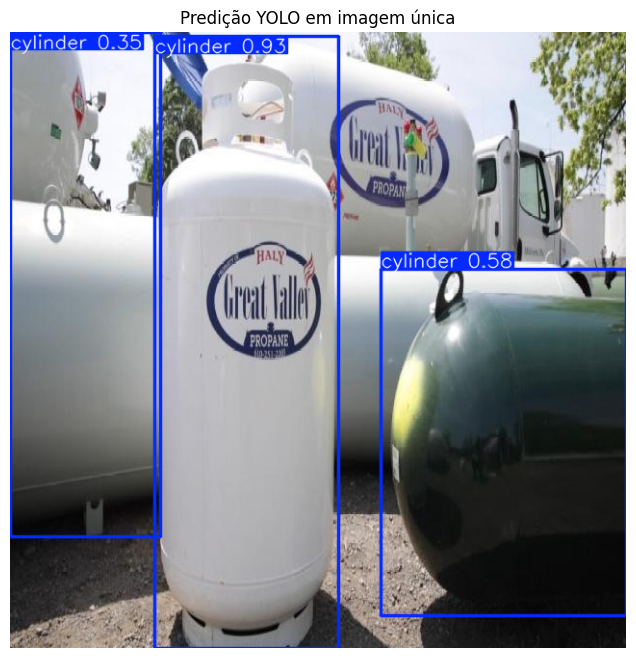

In [32]:
# ============================================================
# Passo 27 — Inferência em uma imagem única
# ============================================================

IMAGEM_EXTERNA = ""  # Exemplo: "/home/usuario/imagem_cilindro.jpg"
SORTEAR_IMAGEM_DO_DATASET = True

if IMAGEM_EXTERNA.strip():
    imagem_teste = Path(IMAGEM_EXTERNA).expanduser()
else:
    imagens_disponiveis = listar_imagens(SOURCE_TEST)
    if len(imagens_disponiveis) == 0:
        raise FileNotFoundError("Nenhuma imagem disponível para teste.")

    if SORTEAR_IMAGEM_DO_DATASET:
        imagem_teste = random.choice(imagens_disponiveis)
    else:
        imagem_teste = imagens_disponiveis[0]

print("Imagem usada:")
print(imagem_teste)

if not imagem_teste.exists():
    raise FileNotFoundError(f"Imagem não encontrada: {imagem_teste}")

results = model_infer.predict(
    source=str(imagem_teste),
    imgsz=IMGSZ,
    conf=CONF,
    iou=IOU,
    device=DEVICE,
    verbose=False,
)

img_result = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Predição YOLO em imagem única")
plt.show()


## Passo 28 — Inferência contínua em vídeo salvo

Este passo aplica o modelo YOLO treinado em um vídeo salvo dentro da pasta:

`vision/datasets/cylinders/videos/`

Ele é recomendado para o Jupyter da UFSC, pois o servidor remoto normalmente não consegue acessar a webcam local do computador do usuário.

Também pode ser usado no VS Code, desde que o vídeo esteja disponível localmente.

In [33]:
# ============================================================
# Passo 28 — Inferência contínua em vídeo salvo
# ============================================================
#
# Uso recomendado:
# - Jupyter da UFSC: usar vídeo salvo.
# - VS Code: também pode usar vídeo salvo.
#
# Pasta monitorada:
# vision/datasets/cylinders/videos/
# ============================================================

from pathlib import Path
import time
import threading

import cv2
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


# ------------------------------------------------------------
# Configurações principais
# ------------------------------------------------------------

VIDEO_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "videos"

EXTENSOES_VIDEO = [
    ".mp4", ".avi", ".mov", ".mkv", ".webm", ".mpeg", ".mpg"
]

PULAR_FRAMES_PADRAO = 1
QUALIDADE_JPEG = 80

# Dispositivo de inferência.
# Usa DEVICE_YOLO se existir; caso contrário, usa DEVICE.
if "DEVICE_YOLO" in globals():
    DISPOSITIVO_INFERENCIA = DEVICE_YOLO
elif "DEVICE" in globals():
    DISPOSITIVO_INFERENCIA = DEVICE
else:
    DISPOSITIVO_INFERENCIA = 0

# Carrega o modelo de inferência, se ainda não existir.
if "model_infer" not in globals():
    if not Path(BEST_MODEL_PATH).exists():
        raise FileNotFoundError(f"Modelo não encontrado: {BEST_MODEL_PATH}")

    print("Carregando modelo de inferência:")
    print(BEST_MODEL_PATH)
    model_infer = YOLO(str(BEST_MODEL_PATH))


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def listar_videos_do_diretorio():
    """
    Lista todos os vídeos disponíveis em vision/datasets/cylinders/videos/.
    """
    VIDEO_DIR.mkdir(parents=True, exist_ok=True)

    videos = []

    for ext in EXTENSOES_VIDEO:
        videos.extend(VIDEO_DIR.glob(f"*{ext}"))
        videos.extend(VIDEO_DIR.glob(f"*{ext.upper()}"))

    videos = sorted(set(videos))

    if len(videos) == 0:
        return [("Nenhum vídeo encontrado", "")]

    return [(video.name, str(video)) for video in videos]


def frame_bgr_para_jpeg_bytes(frame_bgr, qualidade=80):
    """
    Converte frame BGR do OpenCV para bytes JPEG,
    permitindo exibição eficiente no notebook.
    """
    ok, buffer = cv2.imencode(
        ".jpg",
        frame_bgr,
        [int(cv2.IMWRITE_JPEG_QUALITY), int(qualidade)]
    )

    if not ok:
        return None

    return buffer.tobytes()


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

video_dropdown = widgets.Dropdown(
    options=listar_videos_do_diretorio(),
    description="Vídeo:",
    layout=widgets.Layout(width="650px"),
)

botao_atualizar_videos = widgets.Button(
    description="Atualizar lista",
    button_style="info",
    layout=widgets.Layout(width="150px"),
)

pular_frames_widget = widgets.IntSlider(
    value=PULAR_FRAMES_PADRAO,
    min=1,
    max=30,
    step=1,
    description="Pular:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

largura_widget = widgets.IntSlider(
    value=900,
    min=400,
    max=1400,
    step=50,
    description="Largura:",
    continuous_update=False,
    layout=widgets.Layout(width="360px"),
)

repetir_video_widget = widgets.Checkbox(
    value=False,
    description="Repetir vídeo ao terminar",
    indent=False,
    layout=widgets.Layout(width="230px"),
)

botao_iniciar = widgets.Button(
    description="Iniciar detecção contínua",
    button_style="success",
    layout=widgets.Layout(width="230px"),
)

botao_parar = widgets.Button(
    description="Parar",
    button_style="danger",
    layout=widgets.Layout(width="120px"),
)

botao_parar.disabled = True

imagem_saida = widgets.Image(
    format="jpeg",
    layout=widgets.Layout(width="900px", border="1px solid #444")
)

status_label = widgets.HTML(
    value="<b>Status:</b> aguardando início."
)

saida_info = widgets.Output()


# ------------------------------------------------------------
# Controle da execução contínua
# ------------------------------------------------------------

stop_event_video_salvo = threading.Event()
thread_video_salvo = None


def atualizar_layout_imagem(*args):
    imagem_saida.layout.width = f"{largura_widget.value}px"


def atualizar_lista_videos(_=None):
    video_dropdown.options = listar_videos_do_diretorio()

    with saida_info:
        clear_output(wait=True)
        print("Lista de vídeos atualizada.")
        print("Pasta monitorada:")
        print(VIDEO_DIR)


def loop_video_salvo():
    """
    Executa a inferência contínua no vídeo selecionado.
    """
    global botao_iniciar, botao_parar

    try:
        caminho_video = video_dropdown.value

        if caminho_video is None or caminho_video == "":
            with saida_info:
                clear_output(wait=True)
                print("Nenhum vídeo foi encontrado.")
                print("Coloque um vídeo na pasta:")
                print(VIDEO_DIR)

            status_label.value = "<b>Status:</b> nenhum vídeo encontrado."
            return

        caminho_video = Path(caminho_video)

        if not caminho_video.exists():
            with saida_info:
                clear_output(wait=True)
                print("Vídeo selecionado não encontrado:")
                print(caminho_video)

            status_label.value = "<b>Status:</b> vídeo não encontrado."
            return

        cap = cv2.VideoCapture(str(caminho_video))

        if not cap.isOpened():
            with saida_info:
                clear_output(wait=True)
                print("Não foi possível abrir o vídeo:")
                print(caminho_video)

            status_label.value = "<b>Status:</b> erro ao abrir vídeo."
            return

        fps_video = cap.get(cv2.CAP_PROP_FPS)

        if fps_video is None or fps_video <= 1 or fps_video > 120:
            fps_video = 30

        intervalo_minimo = 1.0 / fps_video
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        frame_id = 0
        frames_processados = 0
        tempo_inicio = time.time()

        with saida_info:
            clear_output(wait=True)
            print("Vídeo aberto com sucesso.")
            print("Arquivo:", caminho_video.name)
            print("Total de frames:", total_frames)
            print("FPS estimado:", round(fps_video, 2))
            print("Para encerrar, clique em 'Parar'.")

        while not stop_event_video_salvo.is_set():
            ret, frame = cap.read()

            if not ret:
                if repetir_video_widget.value:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    frame_id = 0
                    continue
                else:
                    break

            frame_id += 1

            if frame_id % int(pular_frames_widget.value) != 0:
                continue

            t0 = time.time()

            results = model_infer.predict(
                source=frame,
                imgsz=IMGSZ,
                conf=CONF,
                iou=IOU,
                device=DISPOSITIVO_INFERENCIA,
                verbose=False,
            )

            annotated = results[0].plot()

            jpeg_bytes = frame_bgr_para_jpeg_bytes(
                annotated,
                qualidade=QUALIDADE_JPEG
            )

            if jpeg_bytes is not None:
                imagem_saida.value = jpeg_bytes

            frames_processados += 1

            tempo_decorrido = time.time() - tempo_inicio
            fps_processamento = frames_processados / max(tempo_decorrido, 1e-6)

            if total_frames > 0:
                status_label.value = (
                    f"<b>Status:</b> rodando | "
                    f"frame {frame_id}/{total_frames} | "
                    f"FPS processamento: {fps_processamento:.2f}"
                )
            else:
                status_label.value = (
                    f"<b>Status:</b> rodando | "
                    f"frame {frame_id} | "
                    f"FPS processamento: {fps_processamento:.2f}"
                )

            tempo_gasto = time.time() - t0
            pausa = max(0.001, min(intervalo_minimo - tempo_gasto, 0.03))
            time.sleep(pausa)

        cap.release()

        status_label.value = (
            f"<b>Status:</b> finalizado | "
            f"frames processados: {frames_processados}"
        )

        with saida_info:
            print()
            print("Execução finalizada.")
            print("Frames lidos:", frame_id)
            print("Frames processados:", frames_processados)

    except Exception as e:
        status_label.value = "<b>Status:</b> erro durante a execução."

        with saida_info:
            clear_output(wait=True)
            print("Erro durante a inferência no vídeo:")
            print(type(e).__name__, "-", e)

    finally:
        botao_iniciar.disabled = False
        botao_parar.disabled = True
        stop_event_video_salvo.clear()


def iniciar_video_salvo(_=None):
    """
    Inicia a inferência contínua em thread separada.
    """
    global thread_video_salvo

    if thread_video_salvo is not None and thread_video_salvo.is_alive():
        with saida_info:
            clear_output(wait=True)
            print("A inferência já está em execução.")
        return

    stop_event_video_salvo.clear()

    botao_iniciar.disabled = True
    botao_parar.disabled = False

    atualizar_layout_imagem()

    thread_video_salvo = threading.Thread(
        target=loop_video_salvo,
        daemon=True
    )

    thread_video_salvo.start()


def parar_video_salvo(_=None):
    """
    Solicita parada da inferência contínua.
    """
    stop_event_video_salvo.set()
    status_label.value = "<b>Status:</b> parando..."


# ------------------------------------------------------------
# Eventos
# ------------------------------------------------------------

botao_atualizar_videos.on_click(atualizar_lista_videos)
botao_iniciar.on_click(iniciar_video_salvo)
botao_parar.on_click(parar_video_salvo)
largura_widget.observe(atualizar_layout_imagem, names="value")

atualizar_layout_imagem()


# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

linha_1 = widgets.HBox([video_dropdown, botao_atualizar_videos])
linha_2 = widgets.HBox([pular_frames_widget, largura_widget, repetir_video_widget])
linha_3 = widgets.HBox([botao_iniciar, botao_parar])

display(linha_1)
display(linha_2)
display(linha_3)
display(status_label)
display(imagem_saida)
display(saida_info)

print("Passo 28 pronto.")
print("Este passo usa somente vídeos salvos.")
print("Pasta de vídeos monitorada:")
print(VIDEO_DIR)

HTML(value='<b>Status:</b> aguardando início.')

Image(value=b'', format='jpeg', layout="Layout(border_bottom='1px solid #444', border_left='1px solid #444', b…

Output()

Passo 28 pronto.
Este passo usa somente vídeos salvos.
Pasta de vídeos monitorada:
/home/eduardo/Documents/BLAZE/vision/datasets/cylinders/videos


## Passo 29 — Inferência em tempo real com webcam local

Este passo é destinado ao uso local no VS Code.

Ele abre a webcam do computador, aplica o modelo YOLO em tempo real e exibe o resultado em uma janela externa do OpenCV.

Também permite escolher se o vídeo processado será salvo ou não.

Não é recomendado para o Jupyter da UFSC, pois o servidor remoto normalmente não acessa a webcam local nem abre janelas gráficas interativas.

In [27]:
# ============================================================
# Passo 29 — Inferência contínua com webcam local no notebook
# ============================================================
#
# Uso recomendado:
# - VS Code local.
# - Webcam local funcionando.
#
# Este passo NÃO usa cv2.imshow().
# A imagem é exibida dentro do notebook usando widgets.Image.
# ============================================================

from pathlib import Path
from datetime import datetime
import time
import threading

import cv2
import torch
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


# ------------------------------------------------------------
# Configurações principais
# ------------------------------------------------------------

WEBCAM_INDEX_PADRAO = 0
QUALIDADE_JPEG = 80

VIDEO_RESULTS_DIR = (
    PROJECT_ROOT
    / "vision"
    / "results"
    / "yolo_cylinder_detector"
    / "videos"
)

VIDEO_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CAMINHO_SAIDA_PADRAO = (
    VIDEO_RESULTS_DIR
    / f"webcam_yolo_{datetime.now().strftime('%Y%m%d_%H%M%S')}.mp4"
)


# ------------------------------------------------------------
# Garante modelo carregado
# ------------------------------------------------------------

if "model_infer" not in globals():
    if not Path(BEST_MODEL_PATH).exists():
        raise FileNotFoundError(f"Modelo não encontrado: {BEST_MODEL_PATH}")

    print("Carregando modelo:")
    print(BEST_MODEL_PATH)
    model_infer = YOLO(str(BEST_MODEL_PATH))


# ------------------------------------------------------------
# Define dispositivo de inferência
# ------------------------------------------------------------

if torch.cuda.is_available():
    if "DEVICE_YOLO" in globals():
        DISPOSITIVO_INFERENCIA = DEVICE_YOLO
    elif "DEVICE" in globals():
        DISPOSITIVO_INFERENCIA = DEVICE
    else:
        DISPOSITIVO_INFERENCIA = 0
else:
    DISPOSITIVO_INFERENCIA = "cpu"

print("Dispositivo de inferência:", DISPOSITIVO_INFERENCIA)


# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def frame_bgr_para_jpeg_bytes(frame_bgr, qualidade=80):
    ok, buffer = cv2.imencode(
        ".jpg",
        frame_bgr,
        [int(cv2.IMWRITE_JPEG_QUALITY), int(qualidade)]
    )

    if not ok:
        return None

    return buffer.tobytes()


# ------------------------------------------------------------
# Widgets
# ------------------------------------------------------------

webcam_index_widget = widgets.IntText(
    value=WEBCAM_INDEX_PADRAO,
    description="Webcam:",
    layout=widgets.Layout(width="170px"),
)

salvar_video_widget = widgets.Checkbox(
    value=False,
    description="Salvar vídeo processado",
    indent=False,
    layout=widgets.Layout(width="230px"),
)

caminho_saida_widget = widgets.Text(
    value=str(CAMINHO_SAIDA_PADRAO),
    description="Salvar em:",
    layout=widgets.Layout(width="850px"),
)

conf_widget = widgets.FloatSlider(
    value=CONF,
    min=0.05,
    max=0.95,
    step=0.05,
    description="Conf:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

iou_widget = widgets.FloatSlider(
    value=IOU,
    min=0.10,
    max=0.95,
    step=0.05,
    description="IoU:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

imgsz_widget = widgets.IntSlider(
    value=IMGSZ,
    min=320,
    max=1280,
    step=32,
    description="ImgSz:",
    continuous_update=False,
    layout=widgets.Layout(width="320px"),
)

largura_widget = widgets.IntSlider(
    value=900,
    min=400,
    max=1400,
    step=50,
    description="Largura:",
    continuous_update=False,
    layout=widgets.Layout(width="360px"),
)

pular_frames_widget = widgets.IntSlider(
    value=1,
    min=1,
    max=10,
    step=1,
    description="Pular:",
    continuous_update=False,
    layout=widgets.Layout(width="300px"),
)

botao_iniciar = widgets.Button(
    description="Iniciar webcam",
    button_style="success",
    layout=widgets.Layout(width="180px"),
)

botao_parar = widgets.Button(
    description="Parar",
    button_style="danger",
    layout=widgets.Layout(width="120px"),
)

botao_parar.disabled = True

imagem_webcam = widgets.Image(
    format="jpeg",
    layout=widgets.Layout(width="900px", border="1px solid #444")
)

status_webcam = widgets.HTML(
    value="<b>Status:</b> aguardando início."
)

saida_webcam = widgets.Output()


# ------------------------------------------------------------
# Controle da execução
# ------------------------------------------------------------

stop_event_webcam = threading.Event()
thread_webcam = None


def atualizar_layout_imagem(*args):
    imagem_webcam.layout.width = f"{largura_widget.value}px"


def atualizar_visibilidade_caminho(*args):
    if salvar_video_widget.value:
        caminho_saida_widget.layout.display = ""
    else:
        caminho_saida_widget.layout.display = "none"


def loop_webcam_notebook():
    cap = None
    writer = None

    try:
        webcam_index = int(webcam_index_widget.value)
        salvar_video = bool(salvar_video_widget.value)
        caminho_saida = Path(caminho_saida_widget.value).expanduser()

        conf_atual = float(conf_widget.value)
        iou_atual = float(iou_widget.value)
        imgsz_atual = int(imgsz_widget.value)
        pular_frames = int(pular_frames_widget.value)

        with saida_webcam:
            clear_output(wait=True)
            print("Abrindo webcam local...")
            print("Webcam index:", webcam_index)
            print("Salvar vídeo:", salvar_video)

            if salvar_video:
                print("Arquivo de saída:")
                print(caminho_saida)

        cap = cv2.VideoCapture(webcam_index, cv2.CAP_V4L2)

        if not cap.isOpened():
            raise RuntimeError(
                "Não foi possível abrir a webcam.\n"
                "Teste webcam 0, 1 ou 2."
            )

        # Ajuste simples de resolução
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

        fps_camera = cap.get(cv2.CAP_PROP_FPS)
        if fps_camera is None or fps_camera <= 1 or fps_camera > 120:
            fps_camera = 30

        # Descarta frames iniciais
        for _ in range(10):
            ret, frame = cap.read()

        ret, frame = cap.read()

        if not ret or frame is None:
            raise RuntimeError("A webcam abriu, mas não entregou frame válido.")

        altura_frame, largura_frame = frame.shape[:2]

        if salvar_video:
            caminho_saida.parent.mkdir(parents=True, exist_ok=True)
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")

            writer = cv2.VideoWriter(
                str(caminho_saida),
                fourcc,
                fps_camera,
                (largura_frame, altura_frame),
            )

            if not writer.isOpened():
                raise RuntimeError(f"Não foi possível criar o vídeo: {caminho_saida}")

        frames_lidos = 0
        frames_processados = 0
        tempo_inicio = time.time()

        status_webcam.value = "<b>Status:</b> rodando."

        while not stop_event_webcam.is_set():
            ret, frame = cap.read()

            if not ret or frame is None:
                print("Falha ao capturar frame.")
                break

            frames_lidos += 1

            if frames_lidos % pular_frames != 0:
                continue

            results = model_infer.predict(
                source=frame,
                imgsz=imgsz_atual,
                conf=conf_atual,
                iou=iou_atual,
                device=DISPOSITIVO_INFERENCIA,
                verbose=False,
            )

            annotated = results[0].plot()

            frames_processados += 1
            tempo_decorrido = time.time() - tempo_inicio
            fps_processamento = frames_processados / max(tempo_decorrido, 1e-6)

            cv2.putText(
                annotated,
                f"FPS: {fps_processamento:.2f}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )

            if writer is not None:
                writer.write(annotated)

            jpeg_bytes = frame_bgr_para_jpeg_bytes(
                annotated,
                qualidade=QUALIDADE_JPEG
            )

            if jpeg_bytes is not None:
                imagem_webcam.value = jpeg_bytes

            status_webcam.value = (
                f"<b>Status:</b> rodando | "
                f"frames processados: {frames_processados} | "
                f"FPS: {fps_processamento:.2f}"
            )

            time.sleep(0.001)

        status_webcam.value = (
            f"<b>Status:</b> finalizado | "
            f"frames processados: {frames_processados}"
        )

        with saida_webcam:
            print()
            print("Execução finalizada.")
            print("Frames lidos:", frames_lidos)
            print("Frames processados:", frames_processados)

            if salvar_video:
                print("Vídeo salvo em:")
                print(caminho_saida)

    except Exception as e:
        status_webcam.value = "<b>Status:</b> erro durante execução."

        with saida_webcam:
            clear_output(wait=True)
            print("Erro na webcam:")
            print(type(e).__name__, "-", e)

    finally:
        if cap is not None:
            cap.release()

        if writer is not None:
            writer.release()

        botao_iniciar.disabled = False
        botao_parar.disabled = True
        stop_event_webcam.clear()


def iniciar_webcam(_=None):
    global thread_webcam

    if thread_webcam is not None and thread_webcam.is_alive():
        with saida_webcam:
            clear_output(wait=True)
            print("A webcam já está em execução.")
        return

    stop_event_webcam.clear()

    botao_iniciar.disabled = True
    botao_parar.disabled = False

    atualizar_layout_imagem()

    thread_webcam = threading.Thread(
        target=loop_webcam_notebook,
        daemon=True
    )

    thread_webcam.start()


def parar_webcam(_=None):
    stop_event_webcam.set()
    status_webcam.value = "<b>Status:</b> parando..."


# ------------------------------------------------------------
# Eventos
# ------------------------------------------------------------

botao_iniciar.on_click(iniciar_webcam)
botao_parar.on_click(parar_webcam)

largura_widget.observe(atualizar_layout_imagem, names="value")
salvar_video_widget.observe(atualizar_visibilidade_caminho, names="value")

atualizar_layout_imagem()
atualizar_visibilidade_caminho()


# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

linha_1 = widgets.HBox([webcam_index_widget, salvar_video_widget])
linha_2 = widgets.HBox([caminho_saida_widget])
linha_3 = widgets.HBox([conf_widget, iou_widget, imgsz_widget])
linha_4 = widgets.HBox([pular_frames_widget, largura_widget])
linha_5 = widgets.HBox([botao_iniciar, botao_parar])

display(linha_1)
display(linha_2)
display(linha_3)
display(linha_4)
display(linha_5)
display(status_webcam)
display(imagem_webcam)
display(saida_webcam)

print("Passo 29 pronto.")
print("Este passo usa a webcam local dentro do notebook, sem cv2.imshow().")
print("Use webcam index 0, conforme teste realizado.")

Dispositivo de inferência: cpu


HTML(value='<b>Status:</b> aguardando início.')

Image(value=b'', format='jpeg', layout="Layout(border_bottom='1px solid #444', border_left='1px solid #444', b…

Output()

Passo 29 pronto.
Este passo usa a webcam local dentro do notebook, sem cv2.imshow().
Use webcam index 0, conforme teste realizado.


## Passo 31 — Caminhos finais

In [36]:
# ============================================================
# Revisão final dos caminhos principais do módulo YOLO
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Caminhos de entrada
# ------------------------------------------------------------

VIDEO_INPUT_DIR = PROJECT_ROOT / "vision" / "datasets" / "cylinders" / "videos"

# ------------------------------------------------------------
# Caminhos de saída
# ------------------------------------------------------------

RESULTS_BASE_DIR = PROJECT_ROOT / "vision" / "results" / "yolo_cylinder_detector"

# Pasta geral de vídeos processados, usada pelo Passo 29
VIDEO_RESULTS_DIR = RESULTS_BASE_DIR / "videos"

# Se PRED_DIR ainda não existir, define uma pasta padrão para predições
if "PRED_DIR" not in globals():
    PRED_DIR = RESULTS_BASE_DIR / "runs" / "predict"

# Se REGISTRO_PATH ainda não existir, define um registro padrão
if "REGISTRO_PATH" not in globals():
    REGISTRO_PATH = RESULTS_BASE_DIR / "registro_experimento_yolo.json"

# Garante que as pastas principais existam
VIDEO_INPUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_BASE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Mostra caminhos finais
# ------------------------------------------------------------

print("=== CAMINHOS FINAIS DO MÓDULO YOLO ===")
print()

print("Projeto BLAZE:")
print(PROJECT_ROOT)
print()

print("Dataset YOLO:")
print(DATASET_DIR)
print("Existe?", Path(DATASET_DIR).exists())
print()

print("YAML local:")
print(DATA_YAML_LOCAL)
print("Existe?", Path(DATA_YAML_LOCAL).exists())
print()

print("Resultados base:")
print(RESULTS_BASE_DIR)
print("Existe?", RESULTS_BASE_DIR.exists())
print()

print("Execução de treino atual:")
print(RUN_DIR)
print("Existe?", Path(RUN_DIR).exists())
print()

print("Melhor modelo atual:")
print(BEST_MODEL_PATH)
print("Existe?", Path(BEST_MODEL_PATH).exists())
print()

print("Último modelo atual:")
print(LAST_MODEL_PATH)
print("Existe?", Path(LAST_MODEL_PATH).exists())
print()

print("Predições em dataset:")
print(PRED_DIR)
print("Existe?", Path(PRED_DIR).exists())
print()

print("Registro JSON:")
print(REGISTRO_PATH)
print("Existe?", Path(REGISTRO_PATH).exists())
print()

print("Vídeos de entrada para o Passo 28:")
print(VIDEO_INPUT_DIR)
print("Existe?", VIDEO_INPUT_DIR.exists())
print()

print("Vídeos processados/salvos pelo Passo 29:")
print(VIDEO_RESULTS_DIR)
print("Existe?", VIDEO_RESULTS_DIR.exists())

=== CAMINHOS FINAIS DO MÓDULO YOLO ===

Projeto BLAZE:
/home/jovyan/compartilhado/eduardofelipe/BLAZE

Dataset YOLO:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/datasets/cylinders/CylinDeRS-1
Existe? True

YAML local:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/datasets/cylinders/CylinDeRS-1/data_local_blaze.yaml
Existe? True

Resultados base:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/results/yolo_cylinder_detector
Existe? True

Execução de treino atual:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_20260531_175236
Existe? True

Melhor modelo atual:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_20260531_175236/weights/best.pt
Existe? True

Último modelo atual:
/home/jovyan/compartilhado/eduardofelipe/BLAZE/vision/results/yolo_cylinder_detector/runs/train/yolov8n_cilindros_blaze_v1_cont_2026053

## Referências técnicas

- Documentação Ultralytics — Treinamento: https://docs.ultralytics.com/modes/train/
- Documentação Ultralytics — Predição: https://docs.ultralytics.com/modes/predict/
- Documentação Ultralytics — Formato de datasets de detecção: https://docs.ultralytics.com/datasets/detect/

Fim do notebook.